# Q3. PCA for Dimension Reduction (30 points)
In this problem, we will implement the Principal Component analysis.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces


def pca(data, num_components):

    # ==================YOUR CODE HERE =================

    # Remember PCA involves
    # (1)estimate and substract the mean,
    # (2) construct the covariance matarix
    # (3) Find the eigenvectors corresponding to the top k eigenvalues
    # Return the eigenvalues and eigenvectors
    # ==================================================

    # Step 1: Compute the mean of the data
    mean_vector = np.mean(data, axis=0, keepdims=True)
    # Step 2: Center the data by subtracting the mean
    centered_data = data - mean_vector
    # Step 3: Compute the covariance matrix
    covariance_matrix = np.cov(centered_data, rowvar=False)
    # Step 4: Compute the eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
    # Step 5: Sort the eigenvalues and eigenvectors in descending order
    sorted_indices = np.argsort(eigenvalues)[::-1]
    sorted_eigenvalues = eigenvalues[sorted_indices]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]
    # Step 6: Select the top k eigenvalues and corresponding eigenvectors
    top_eigenvalues = sorted_eigenvalues[:num_components]
    top_eigenvectors = sorted_eigenvectors[:, :num_components]

    return top_eigenvalues, top_eigenvectors



# The following code help you to visualize your eigenvectors

data = fetch_olivetti_faces().data

num_components = 20  # Number of principal components
eigenvalues, principal_components = pca(data, num_components)

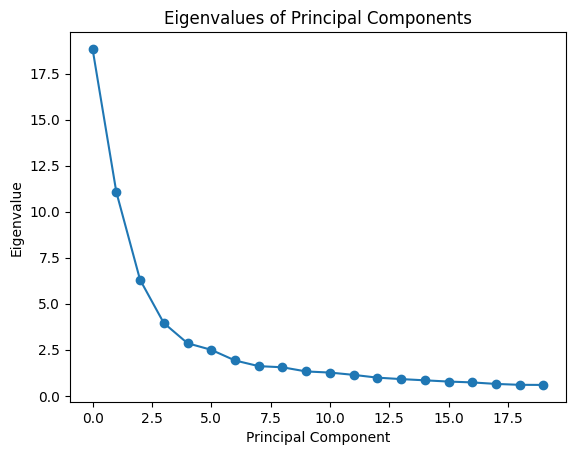

In [6]:

# ==================YOUR CODE HERE =================

# Plot the eigenvalues in descending orders.

# ==================================================
plt.plot(eigenvalues, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.title('Eigenvalues of Principal Components')
plt.show()

Eigenfaces shape: (20, 64, 64)


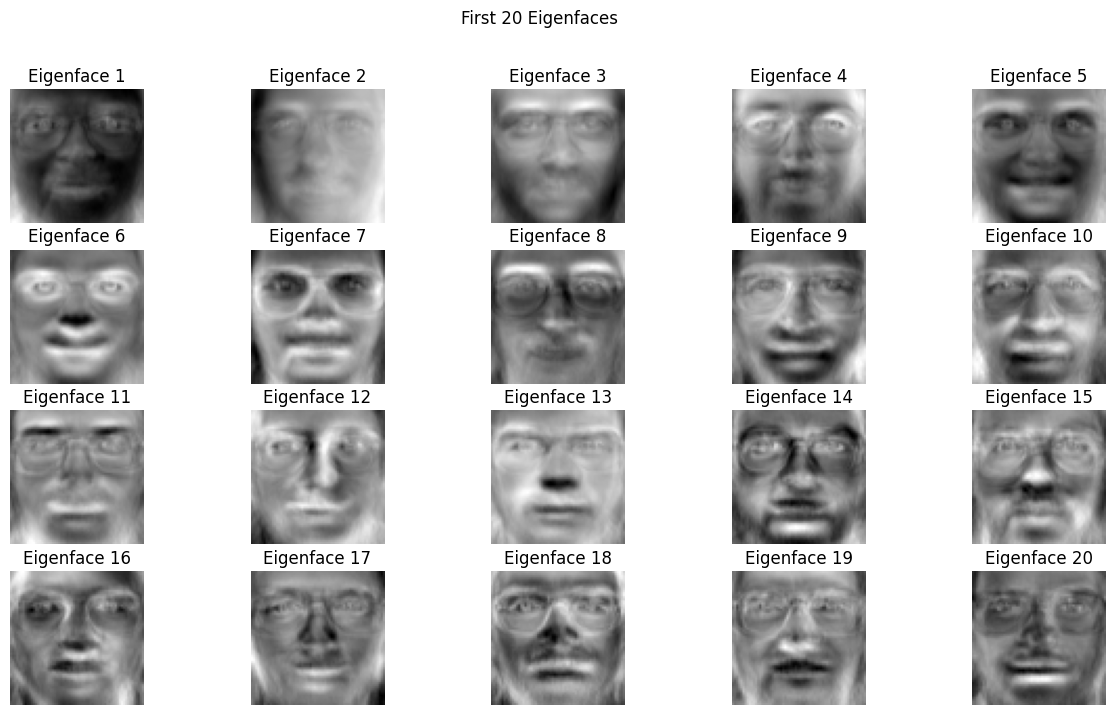

In [7]:
# Eigenfaces would be the principal components reshaped as images
eigenfaces = principal_components.T.reshape((-1, 64, 64))
print("Eigenfaces shape:", eigenfaces.shape)

# Visualize the first 20 eigenfaces
plt.figure(figsize=(15, 8))
for i, eigenface in enumerate(eigenfaces):
    plt.subplot(4, 5, i + 1)
    plt.imshow(eigenface.reshape(64, 64), cmap='gray')
    plt.title(f'Eigenface {i+1}')
    plt.axis('off')
plt.suptitle('First 20 Eigenfaces')
plt.show()

## Answer the following questions

1. When you rerun PCA with different choices of "number_of_components" do they return the same or different solutions? Why?

2. How would you interpret the eigenfaces above?